# AMD Stock Price Prediction with predict

This notebook walks through using `predict` to forecast AMD (Advanced Micro Devices) closing prices. We'll train the LSTM with both the PyTorch and JAX backends and compare results.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from predict.config import Config
from predict.data import fetch_market_data, engineer_features, prepare_arrays, prepare_data

/Users/asheslab/Documents/CV/predict/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Explore the raw data

Pull AMD historical prices and take a look at what we're working with.

In [2]:
cfg = Config(ticker="AMD", start_date="2018-01-01", end_date="2025-12-31")
df = fetch_market_data(cfg)

print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")
df.describe().round(2)

Date range: 2018-01-02 to 2025-12-30
Total trading days: 2010


Price,Close,Volume,High,Low,Open
count,2010.00,2.010000e+03,2010.00,2010.00,2010.00
mean,89.64,6.478417e+07,91.43,87.82,89.68
std,53.25,3.276013e+07,54.35,52.20,53.36
min,9.53,7.956800e+06,9.77,9.04,9.08
25%,42.79,4.253458e+07,43.50,41.84,42.54
50%,87.90,5.587380e+07,89.84,85.89,87.88
75%,120.63,7.935308e+07,123.06,118.55,120.67
max,264.33,3.250584e+08,267.08,257.40,264.19


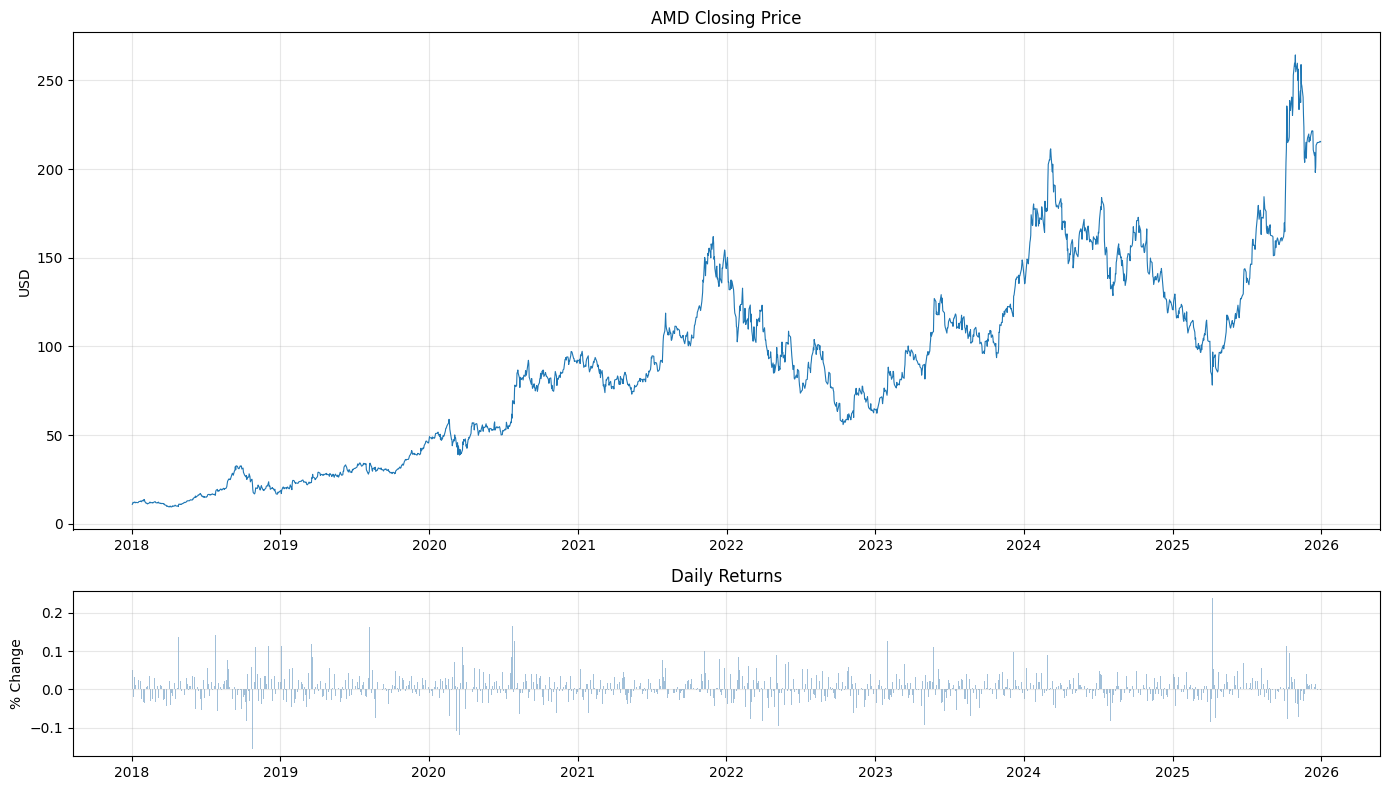

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(df.index, df["Close"], linewidth=0.8)
axes[0].set_title("AMD Closing Price")
axes[0].set_ylabel("USD")
axes[0].grid(True, alpha=0.3)

# daily returns
returns = df["Close"].pct_change().dropna()
axes[1].bar(returns.index, returns.values, width=1, alpha=0.5, color="steelblue")
axes[1].set_title("Daily Returns")
axes[1].set_ylabel("% Change")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Feature engineering

Raw OHLC prices are nearly perfectly correlated (all ~1.0). We replace High/Low/Open with derived features: daily Range (High - Low) and Intraday Return ((Close - Open) / Open). This gives the model 4 non-redundant signals.

/var/folders/f5/16s1276955v04xzgpdv_cf800000gn/T/ipykernel_74767/3692855136.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


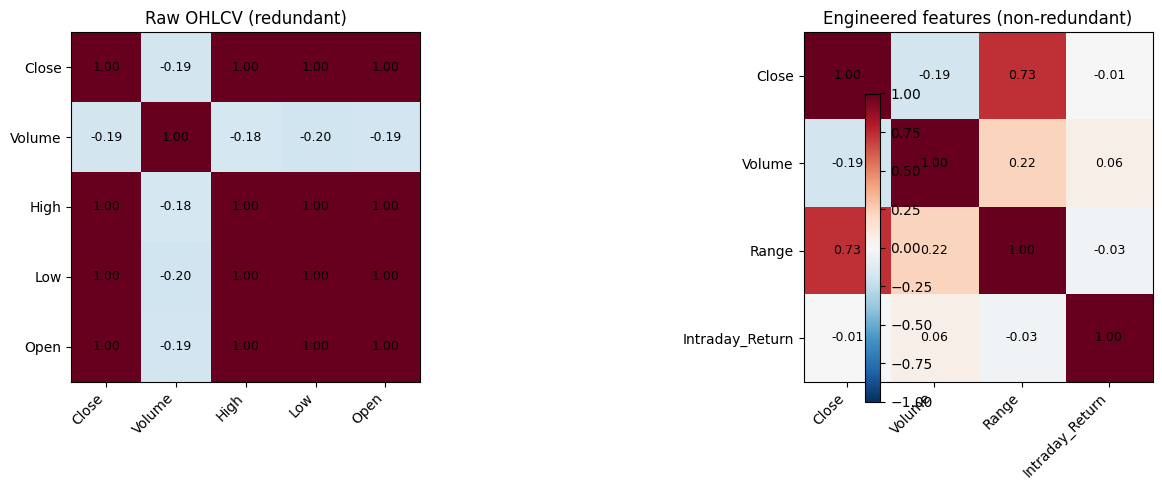

In [4]:
cfg = Config(ticker="AMD", start_date="2018-01-01", end_date="2025-12-31")
raw = fetch_market_data(cfg)

# show why we need feature engineering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw correlations
raw_corr = raw.corr()
im1 = axes[0].imshow(raw_corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(raw_corr.columns)))
axes[0].set_yticks(range(len(raw_corr.columns)))
axes[0].set_xticklabels(raw_corr.columns, rotation=45, ha="right")
axes[0].set_yticklabels(raw_corr.columns)
for i in range(len(raw_corr)):
    for j in range(len(raw_corr)):
        axes[0].text(j, i, f"{raw_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
axes[0].set_title("Raw OHLCV (redundant)")

# engineered correlations
eng = engineer_features(raw, cfg)
eng_corr = eng.corr()
im2 = axes[1].imshow(eng_corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(eng_corr.columns)))
axes[1].set_yticks(range(len(eng_corr.columns)))
axes[1].set_xticklabels(eng_corr.columns, rotation=45, ha="right")
axes[1].set_yticklabels(eng_corr.columns)
for i in range(len(eng_corr)):
    for j in range(len(eng_corr)):
        axes[1].text(j, i, f"{eng_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
axes[1].set_title("Engineered features (non-redundant)")

fig.colorbar(im2, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 3. Train with PyTorch backend

In [5]:
import torch
from predict.train import train_model
from predict.model import LSTMForecaster

cfg_amd = Config(ticker="AMD", start_date="2018-01-01", end_date="2025-12-31", max_epochs=50)
torch.manual_seed(cfg_amd.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

train_loader, val_loader, test_loader, _, target_scaler, test_dates = prepare_data(cfg_amd)
print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

pt_model = train_model(cfg_amd, train_loader, val_loader, device)

Device: mps
Train: 1365 | Val: 292 | Test: 293


In [6]:
# get pytorch predictions
pt_model.eval()
pt_preds, pt_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = pt_model(X_batch.to(device)).cpu().numpy()
        pt_preds.append(preds)
        pt_targets.append(y_batch.numpy())

pt_preds = np.concatenate(pt_preds).reshape(-1, 1)
pt_targets = np.concatenate(pt_targets).reshape(-1, 1)

# invert scaling back to USD
pt_pred_prices = target_scaler.inverse_transform(pt_preds).ravel()
pt_true_prices = target_scaler.inverse_transform(pt_targets).ravel()

## 4. Train with JAX backend

In [7]:
from predict.train_jax import train_model_jax, predict_jax

arrays = prepare_arrays(cfg_amd)
X_train, y_train = arrays["train"]
X_val, y_val = arrays["val"]
X_test, y_test = arrays["test"]

state = train_model_jax(cfg_amd, (X_train, y_train), (X_val, y_val))

jax_preds_scaled = predict_jax(state, X_test, batch_size=cfg_amd.batch_size)
jax_pred_prices = arrays["target_scaler"].inverse_transform(jax_preds_scaled.reshape(-1, 1)).ravel()
jax_true_prices = arrays["target_scaler"].inverse_transform(y_test.reshape(-1, 1)).ravel()

## 5. Compare both backends

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calc_metrics(true, pred):
    return {
        "RMSE": f"${np.sqrt(mean_squared_error(true, pred)):.2f}",
        "MAE": f"${mean_absolute_error(true, pred):.2f}",
        "R²": f"{r2_score(true, pred):.4f}",
    }

results = pd.DataFrame({
    "PyTorch": calc_metrics(pt_true_prices, pt_pred_prices),
    "JAX/Flax": calc_metrics(jax_true_prices, jax_pred_prices),
})
results

,PyTorch,JAX/Flax
RMSE,$22.83,$21.21
MAE,$10.96,$13.64
R²,0.7563,0.7896


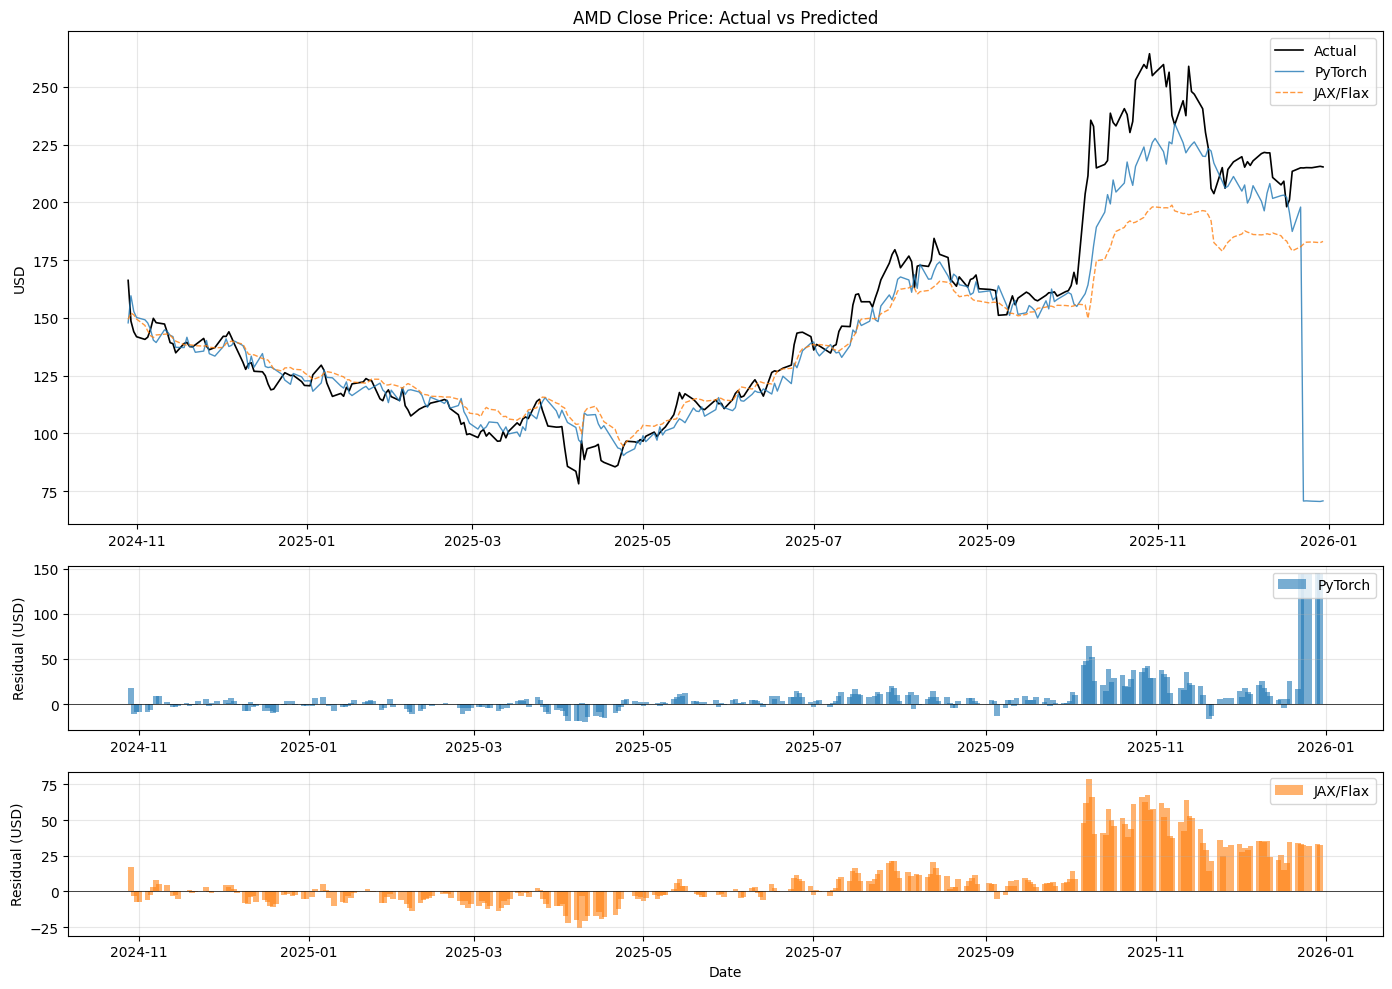

In [9]:
n = min(len(test_dates), len(pt_true_prices), len(jax_pred_prices))
dates = test_dates[:n]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1, 1]})

# predictions overlay
axes[0].plot(dates, pt_true_prices[:n], label="Actual", linewidth=1.2, color="black")
axes[0].plot(dates, pt_pred_prices[:n], label="PyTorch", linewidth=1.0, alpha=0.8)
axes[0].plot(dates, jax_pred_prices[:n], label="JAX/Flax", linewidth=1.0, alpha=0.8, linestyle="--")
axes[0].set_title("AMD Close Price: Actual vs Predicted")
axes[0].set_ylabel("USD")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# pytorch residuals
axes[1].bar(dates, pt_true_prices[:n] - pt_pred_prices[:n], width=2, alpha=0.6, color="tab:blue", label="PyTorch")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Residual (USD)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# jax residuals
axes[2].bar(dates, jax_true_prices[:n] - jax_pred_prices[:n], width=2, alpha=0.6, color="tab:orange", label="JAX/Flax")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_ylabel("Residual (USD)")
axes[2].set_xlabel("Date")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Prediction error distribution

Histogram of residuals for both backends. Centered near zero is good, wide tails mean the model struggles with large moves.

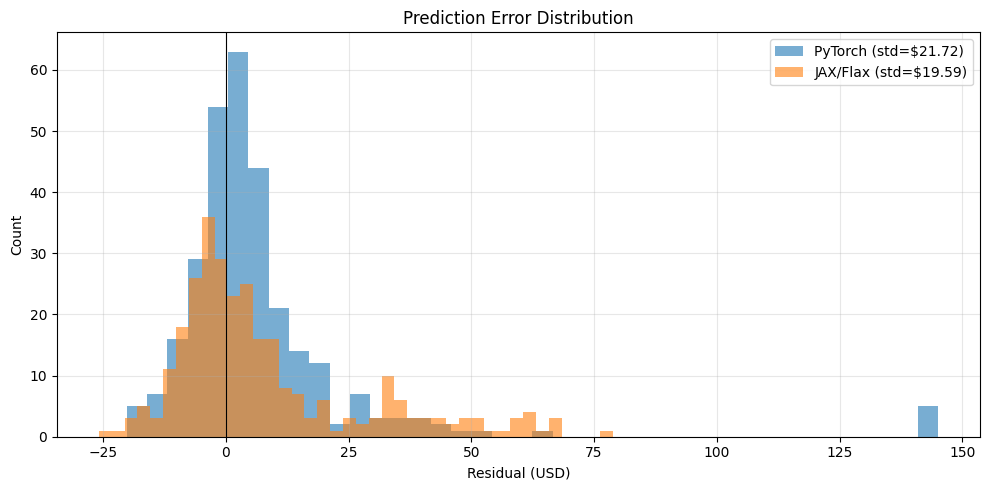

In [10]:
pt_residuals = pt_true_prices[:n] - pt_pred_prices[:n]
jax_residuals = jax_true_prices[:n] - jax_pred_prices[:n]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pt_residuals, bins=40, alpha=0.6, label=f"PyTorch (std=${np.std(pt_residuals):.2f})", color="tab:blue")
ax.hist(jax_residuals, bins=40, alpha=0.6, label=f"JAX/Flax (std=${np.std(jax_residuals):.2f})", color="tab:orange")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Residual (USD)")
ax.set_ylabel("Count")
ax.set_title("Prediction Error Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Rolling prediction accuracy

7-day rolling RMSE to see where the model does well vs. where it struggles.

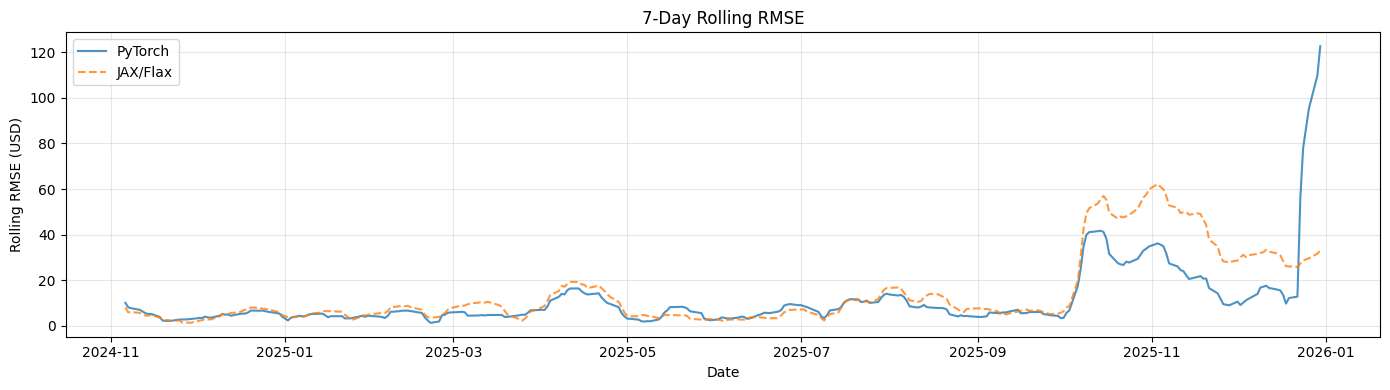

In [11]:
window = 7

pt_rolling_rmse = pd.Series(pt_residuals**2).rolling(window).mean().apply(np.sqrt)
jax_rolling_rmse = pd.Series(jax_residuals**2).rolling(window).mean().apply(np.sqrt)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, pt_rolling_rmse, label="PyTorch", alpha=0.8)
ax.plot(dates, jax_rolling_rmse, label="JAX/Flax", alpha=0.8, linestyle="--")
ax.set_ylabel("Rolling RMSE (USD)")
ax.set_xlabel("Date")
ax.set_title(f"{window}-Day Rolling RMSE")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Directional accuracy: 51.0% (149/292 days)
Buy signals: 136 | Sell signals: 156


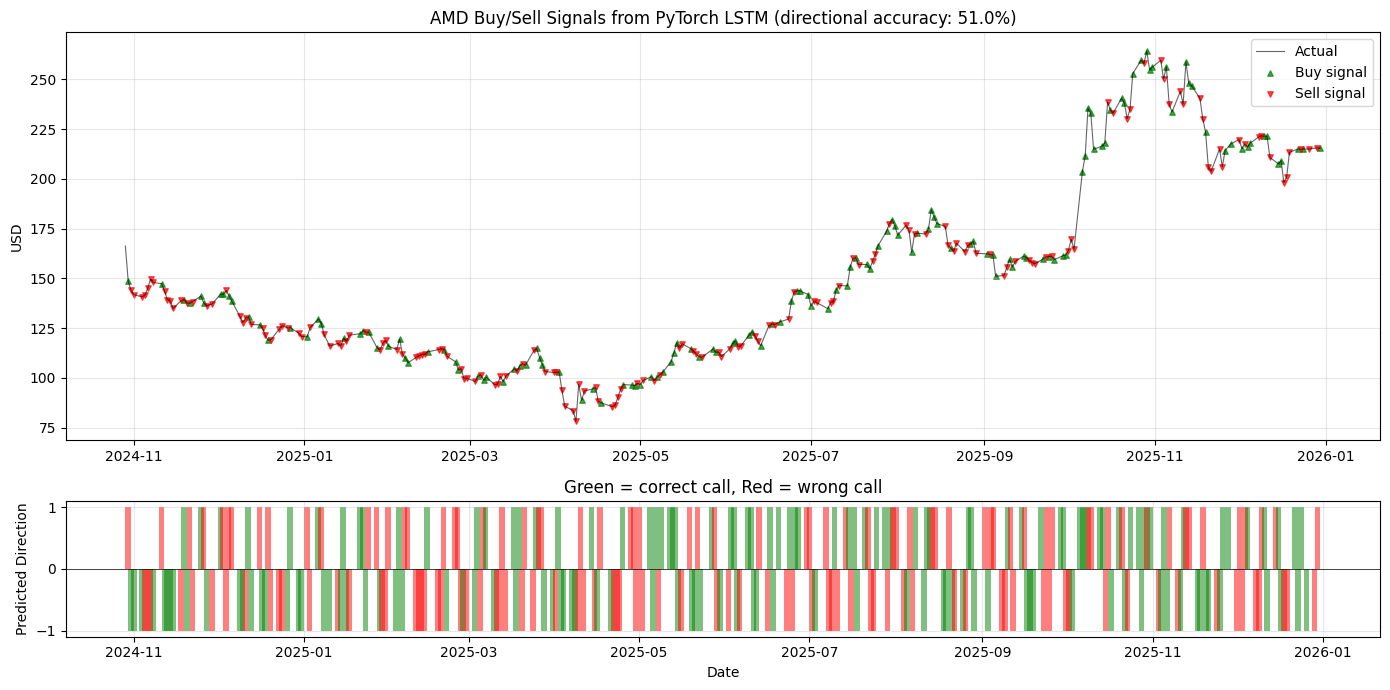


⚠️  This is NOT financial advice. This is a model demonstration only.


In [12]:
# predicted direction vs actual direction
pred_direction = np.sign(np.diff(pt_pred_prices[:n]))
actual_direction = np.sign(np.diff(pt_true_prices[:n]))
signal_dates = dates[1:n]

# buy = predicted up, sell = predicted down
buy_mask = pred_direction > 0
sell_mask = pred_direction < 0
correct = pred_direction == actual_direction

accuracy = np.mean(correct) * 100
print(f"Directional accuracy: {accuracy:.1f}% ({int(np.sum(correct))}/{len(correct)} days)")
print(f"Buy signals: {np.sum(buy_mask)} | Sell signals: {np.sum(sell_mask)}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [3, 1]})

# price with buy/sell markers
axes[0].plot(dates[:n], pt_true_prices[:n], linewidth=0.8, color="black", alpha=0.6, label="Actual")
axes[0].scatter(signal_dates[buy_mask], pt_true_prices[1:n][buy_mask],
               marker="^", color="green", s=15, alpha=0.7, label="Buy signal")
axes[0].scatter(signal_dates[sell_mask], pt_true_prices[1:n][sell_mask],
               marker="v", color="red", s=15, alpha=0.7, label="Sell signal")
axes[0].set_title(f"AMD Buy/Sell Signals from PyTorch LSTM (directional accuracy: {accuracy:.1f}%)")
axes[0].set_ylabel("USD")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# correct vs incorrect calls
colors = ["green" if c else "red" for c in correct]
axes[1].bar(signal_dates, pred_direction, width=2, color=colors, alpha=0.5)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Predicted Direction")
axes[1].set_xlabel("Date")
axes[1].set_title("Green = correct call, Red = wrong call")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚠️  This is NOT financial advice. This is a model demonstration only.")

## 8. Buy / Sell Signal

Simple signal based on the PyTorch model's predicted next-day move: if the model predicts tomorrow's close will be higher than today's actual close, that's a **Buy** signal; lower is **Sell**.

**This is NOT financial advice.** This is a demonstration of how a predictive model's output can be turned into a directional signal. Do not use this to make real trading decisions.